In [1]:
import serial
from ReadWrite import ReadWrite
import pandas as pd
from matplotlib import pyplot as plt
from Network import RKMNetwork
from func_timeout import func_timeout, FunctionTimedOut
import time
import ast
import numpy as np
from scipy.interpolate import make_smoothing_spline
import os
lam = 20
import random

In [2]:
port = "COM4"  # Replace with your serial port
baudrate = 250000
ser = serial.Serial(port, baudrate)
ser.is_open

True

In [10]:
ser.close()

In [3]:
RW = ReadWrite(ser)

Graph with 6 nodes and 8 edges
  name  isWeight Anode Bnode
0  BV0         0    A0    V0
1  BV1         0    A0    V1
2  BH0         0    A0    H0
3  BH1         0    A0    H1
4  W00         1    V0    H0
5  W01         1    V0    H1
6  W10         1    V1    H0
7  W11         1    V1    H1
  name
0   A0
1   H0
2   H1
3   V0
4   V1


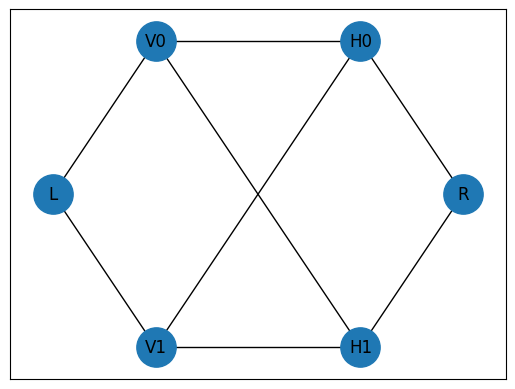

In [4]:
numV = 2
numH = 2

net = RKMNetwork(numV,numH)

net.draw_network()

print(net.edge)
print(net.node)

In [5]:
def cleanup_dict(thisdict): 
    aConvert = (3.3)/(4095.)
    ki = thisdict['ki']
    DA = thisdict['DA']
    DB = thisdict['DB']
    RA = thisdict['RA']
    RB = thisdict['RB']
    
    nmestimes = 5. #thisdict['nmestimes']
    aConvert = aConvert*1/nmestimes
    
    if not (net.run_nodechecks(DA, DB) and net.run_nodechecks(RA, RB)):
        print("failed nodecheck")
        return None
    
    edges = dict(zip(net.edge.name, ki))
    
    Dnodes = dict(zip(net.edge.Anode, DA))
    Dnodes.update(dict(zip(net.edge.Bnode, DB)))
    
    Rnodes = dict(zip(net.edge.Anode, RA))
    Rnodes.update(dict(zip(net.edge.Bnode, RB)))

    
    newdict = {'epoch': thisdict['epoch'],  'trainingstep': thisdict['epoch'], 
               'Vtest': thisdict['Vtest'], 'Vrecon': thisdict['Vrecon'],
               'Vtest_det': thisdict['Vtest_det'], 'Vrecon_det': thisdict['Vrecon_det']}
    newdict.update(edges)
    
    for key in Dnodes:
        newdict['D' + key] = Dnodes[key]
    
    for key in Rnodes:
        newdict['R' + key] = Rnodes[key]

    try:
        azero = np.array(thisdict['analogZero'], dtype='float')*aConvert
        newdict['analogZero'] = azero
        
        analogV = thisdict['analogV']
        analogH = thisdict['analogH']
        for i, val in enumerate(analogV):
            newdict['aV' + str(i)] = val*aConvert
        
        for i, val in enumerate(analogH):
            newdict['aH' + str(i)] = val*aConvert
    except Exception as e: 
        print('Epoch', newdict['epoch'])
        print(e)
        
    return newdict

In [6]:
# RW.send_recieve("resetval;0;")
# RW.send_recieve("reset;")

rand1 = 0
rand2 = 0
while(rand1==rand2):
    rand1 = random.uniform(0,100)
    rand2 = random.uniform(0,100)

RW.send_recieve("seed;1;{};".format(rand1))
RW.send_recieve("seed;2;{};".format(rand2))

time.sleep(1)

RW.send_message("mes;")
mes = RW.measure()
eki = mes['ki']
DA = mes['DA']
DB = mes['DB']
RA = mes['RA']
RB = mes['RB']

print(net.run_nodechecks(DA, DB))
print(net.run_nodechecks(RA, RB))

print(dict(zip(net.edge.name, eki)))

d1 = dict(zip(net.edge.Anode, DA))
d1.update(dict(zip(net.edge.Bnode, DB)))

r1 = dict(zip(net.edge.Anode, RA))
r1.update(dict(zip(net.edge.Bnode, RB)))

print(d1, r1)

board, 1
seed, 79
finished
board, 2
seed, 64
finished
ki, [-1, -1, -1, -1, -1, -1, -1, -1]
DA, [1, 1, 1, 1, 1, 1, 1, 1]
DB, [1, 1, 1, 1, 1, 1, 1, 1]
RA, [1, 1, 1, 1, 1, 1, 1, 1]
RB, [1, 1, 1, 1, 1, 1, 1, 1]
finished
True
True
{'BV0': -1, 'BV1': -1, 'BH0': -1, 'BH1': -1, 'W00': -1, 'W01': -1, 'W10': -1, 'W11': -1}
{'A0': 1, 'V0': 1, 'V1': 1, 'H0': 1, 'H1': 1} {'A0': 1, 'V0': 1, 'V1': 1, 'H0': 1, 'H1': 1}


In [7]:
RW.send_recieve("reset;")

time.sleep(1)

RW.send_message("ames;1;")
mes = RW.measure()

reset
finished
nmestimes, 5
analogZero, 12111
analogV, [12118, 12111]
finished


In [9]:
aConvert = (3.3)/(4095.)

RW.send_recieve("fb;0;")
RW.send_recieve("clamp;1;0;")
time.sleep(1)
RW.send_message("ames;1;")
mes = RW.measure()

newmes = {}
newmes['analogZero'] = int(mes['analogZero'])/int(mes['nmestimes'])*aConvert
newmes['analogV'] = np.array([int(x) for x in mes['analogV']])/int(mes['nmestimes'])*aConvert

newmes

FB, 0
finished
clamped_vals, [1, 0]
finished
nmestimes, 5
analogZero, 12115
analogV, [18174, 12122]
finished


{'analogZero': 1.9526007326007326, 'analogV': array([2.92914286, 1.95372894])}

In [64]:
# get an ensemble of trainings

ensemblename = 'longtrain_500mV_L2_1em5'
epochs= 1000
trials = 10
alpha = 1
kwvar = 30
kbvar = 5
L2 = 1
L2maxexp = 5
detinf = 1
measureEvery = 10
temp = 500

if not os.path.exists('data/trainings/{}/'.format(ensemblename)):
        os.mkdir('data/trainings/{}/'.format(ensemblename))

RW.send_recieve("alpha;{};".format(alpha))
time.sleep(1)
RW.send_recieve("kwvar;{};".format(kwvar))
time.sleep(1)
RW.send_recieve("kbvar;{};".format(kbvar))
time.sleep(1)
RW.send_recieve("L2;{};".format(L2))
time.sleep(1)
RW.send_recieve("L2max;{};".format(str(int(L2maxexp))))
time.sleep(1)
RW.send_recieve("detinf;{};".format(detinf))
time.sleep(1)
RW.send_recieve("measureEvery;{};".format(measureEvery))
time.sleep(1)

for t in range(trials):
    print('Trial {}'.format(t))

    RW.send_recieve("fb;0;", suppress=True)
    time.sleep(1)
    RW.send_recieve("useprev;0;", suppress=True)
    time.sleep(1)
    RW.send_recieve("clamp;0;0;", suppress=True)
    time.sleep(1)
    RW.send_recieve("reset;", suppress=True)
    time.sleep(1)
    RW.send_recieve("norm;", suppress=True)
    RW.clear_output()
    time.sleep(1)
    RW.send_message("mes;")
    eki = RW.measure()['ki']

    first = dict(zip(net.edge.name, eki))
    first['epoch'] = -1
    first['trainingstep'] = -1

    RW.send_message("train;{};".format(epochs))
    listodicts = RW.train_measure()

    listodicts[0].update(first)
    try:
        del listodicts[0]['finalizereconstruct']
        del listodicts[0]['testidx']
    except:
        print(listodicts[0].keys())

    for i in range(1, len(listodicts)):
        listodicts[i] = cleanup_dict(listodicts[i])

    df = pd.DataFrame(listodicts)
    # hyperparams
    df['L2'] = float(L2)/10**L2maxexp
    df['alpha'] = alpha
    df['kwvar'] = kwvar
    df['kbvar'] = kbvar
    df['temp'] = temp
    
    df.epoch = pd.to_numeric(df.epoch)
    df.trainingstep = pd.to_numeric(df.trainingstep)
    
    MSEs = []

    for epoch in df.epoch:
        row = df[df.epoch == epoch].iloc[0]


        Vtest = np.array(row.Vtest).T
        Vrecon = np.array(row.Vrecon).T
        MSE = np.mean(np.linalg.norm(Vtest-Vrecon, axis=0))
        MSEs.append(MSE)
    

    MSEs = np.array(MSEs)
    df['MSE'] = MSEs
    print('Done with training')
    df.to_csv('data/trainings/{}/train{}.csv'.format(ensemblename, str(t).zfill(2)))

alpha, 1
finished
kwvar, 30
finished
kbvar, 5
finished
L2, 1
finished
L2max, 5
finished
detInf, 1
finished
measureEvery, 10
finished
Trial 0
ki, [5, 5, 0, 0, 22, 2, -11, -27]
DA, [1, 1, 1, 1, 0, 0, 0, 0]
DB, [0, 0, 1, 0, 1, 0, 1, 0]
RA, [1, 1, 1, 1, 0, 0, 1, 1]
RB, [0, 1, 1, 1, 1, 1, 1, 1]
finished
Done with training
Trial 1
ki, [5, 5, 0, 0, -5, -27, 4, -26]
DA, [1, 1, 1, 1, 0, 0, 1, 1]
DB, [0, 1, 0, 1, 0, 1, 0, 1]
RA, [1, 1, 1, 1, 0, 0, 1, 1]
RB, [0, 1, 1, 0, 1, 0, 1, 0]
finished
Done with training
Trial 2
ki, [5, 5, 0, 0, 20, -26, 29, 25]
DA, [1, 1, 1, 1, 1, 1, 0, 0]
DB, [1, 0, 1, 0, 1, 0, 1, 0]
RA, [1, 1, 1, 1, 1, 1, 0, 0]
RB, [1, 0, 1, 0, 1, 0, 1, 0]
finished
Done with training
Trial 3
ki, [5, 5, 0, 0, -8, 8, 1, -7]
DA, [1, 1, 1, 1, 0, 0, 1, 1]
DB, [0, 1, 1, 1, 1, 1, 1, 1]
RA, [1, 1, 1, 1, 1, 1, 1, 1]
RB, [1, 1, 0, 1, 0, 1, 0, 1]
finished
Done with training
Trial 4
ki, [5, 5, 0, 0, 6, -15, 11, 18]
DA, [1, 1, 1, 1, 0, 0, 0, 0]
DB, [0, 0, 1, 0, 1, 0, 1, 0]
RA, [1, 1, 1, 1, 0, 0, 1, 1

In [43]:
df

,Vtest_det,Vrecon_det,Vtest,Vrecon,BV0,BV1,BH0,BH1,W00,W01,...,aV0,aV1,aH0,aH1,L2,alpha,kwvar,kbvar,temp,MSE
0,"[[1, 0], [0, 1], [1, 0], [1, 0], [0, 1], [0, 1...","[[1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1...","[[1, 0], [0, 1], [1, 0], [1, 0], [0, 1], [0, 1...","[[0, 1], [0, 1], [0, 0], [0, 0], [0, 0], [0, 0...",5,5,0,0,-29,-17,...,NaN,NaN,NaN,NaN,0.0,1,30,5,500,0.874264
1,"[[1, 0], [0, 1], [1, 0], [1, 0], [0, 1], [0, 1...","[[1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1...","[[1, 0], [0, 1], [1, 0], [1, 0], [0, 1], [0, 1...","[[0, 1], [0, 1], [1, 1], [0, 1], [0, 0], [1, 0...",3,6,0,0,-30,-18,...,1.934227,1.938579,1.907956,1.928425,0.0,1,30,5,500,0.824264
2,"[[1, 0], [0, 1], [1, 0], [1, 0], [0, 1], [0, 1...","[[1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1...","[[1, 0], [0, 1], [1, 0], [1, 0], [0, 1], [0, 1...","[[1, 0], [1, 1], [0, 0], [1, 0], [1, 0], [1, 0...",3,6,2,-2,-29,-19,...,1.957275,1.957114,1.869114,1.909729,0.0,1,30,5,500,0.853553
3,"[[1, 0], [0, 1], [1, 0], [1, 0], [0, 1], [0, 1...","[[1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1...","[[1, 0], [0, 1], [1, 0], [1, 0], [0, 1], [0, 1...","[[0, 0], [1, 0], [1, 1], [0, 1], [0, 1], [0, 1...",4,7,2,-2,-28,-19,...,1.912791,1.927619,1.918755,1.935516,0.0,1,30,5,500,0.844975
4,"[[1, 0], [0, 1], [1, 0], [1, 0], [0, 1], [0, 1...","[[1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1...","[[1, 0], [0, 1], [1, 0], [1, 0], [0, 1], [0, 1...","[[0, 1], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1...",5,8,2,-2,-27,-19,...,1.914886,1.930359,1.920689,1.934872,0.0,1,30,5,500,0.715685
5,"[[1, 0], [0, 1], [1, 0], [1, 0], [0, 1], [0, 1...","[[1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1...","[[1, 0], [0, 1], [1, 0], [1, 0], [0, 1], [0, 1...","[[0, 1], [1, 0], [1, 0], [1, 0], [0, 0], [0, 1...",6,10,0,0,-28,-17,...,1.892161,1.915853,1.952278,1.953729,0.0,1,30,5,500,0.815685
6,"[[1, 0], [0, 1], [1, 0], [1, 0], [0, 1], [0, 1...","[[1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1...","[[1, 0], [0, 1], [1, 0], [1, 0], [0, 1], [0, 1...","[[1, 0], [0, 1], [1, 0], [0, 1], [0, 1], [1, 0...",4,11,-1,0,-29,-18,...,1.935194,1.944381,1.906828,1.928103,0.0,1,30,5,500,0.662132
7,"[[1, 0], [0, 1], [1, 0], [1, 0], [0, 1], [0, 1...","[[1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1...","[[1, 0], [0, 1], [1, 0], [1, 0], [0, 1], [0, 1...","[[1, 1], [1, 1], [1, 1], [1, 0], [1, 0], [1, 0...",6,10,1,0,-27,-17,...,1.916337,1.934549,1.920527,1.939223,0.0,1,30,5,500,0.694975
8,"[[1, 0], [0, 1], [1, 0], [1, 0], [0, 1], [0, 1...","[[1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1...","[[1, 0], [0, 1], [1, 0], [1, 0], [0, 1], [0, 1...","[[0, 0], [0, 0], [1, 1], [1, 0], [1, 0], [1, 1...",6,9,3,-2,-26,-18,...,1.962755,1.961143,1.884103,1.908440,0.0,1,30,5,500,0.953553
9,"[[1, 0], [0, 1], [1, 0], [1, 0], [0, 1], [0, 1...","[[1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1...","[[1, 0], [0, 1], [1, 0], [1, 0], [0, 1], [0, 1...","[[1, 0], [0, 1], [1, 0], [1, 1], [1, 1], [1, 1...",4,11,1,-2,-28,-19,...,1.933260,1.941319,1.911824,1.923590,0.0,1,30,5,500,0.682843


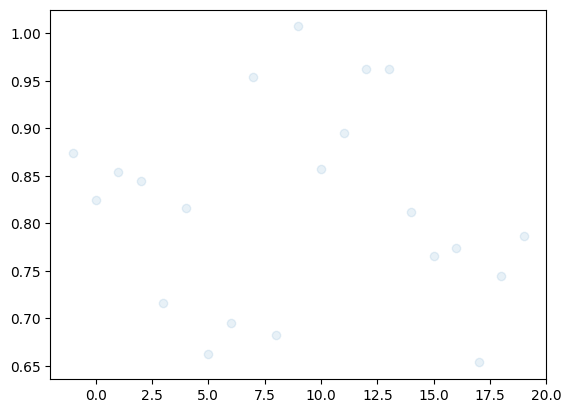

In [44]:
plt.scatter(df.epoch, df.MSE, alpha=0.1)
# plt.plot(df.trainingstep, df.MSE)|

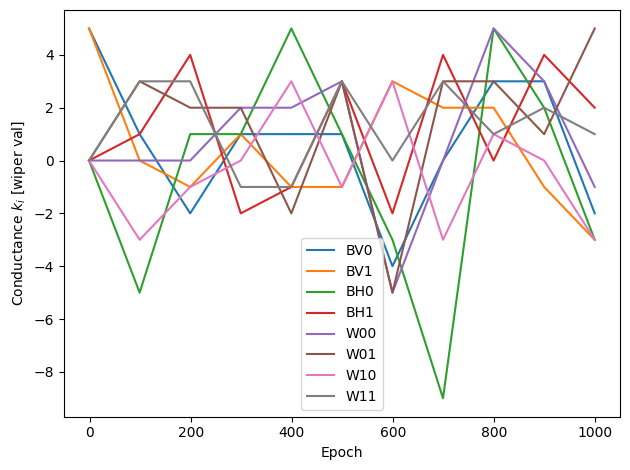

In [110]:
fig, ax = plt.subplots()
for c in df.columns:
    if c[0] == "B" or c[0] == "W":
        ax.plot(df.epoch, df[c], label = c)
ax.legend()

ax.set_xlabel("Epoch")
ax.set_ylabel('Conductance $k_i$ [wiper val]')
fig.tight_layout()

-1
0.7414213562373095


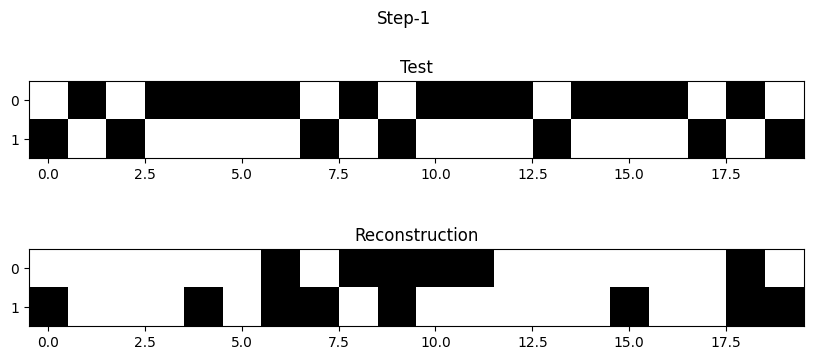

999
0.8828427124746192


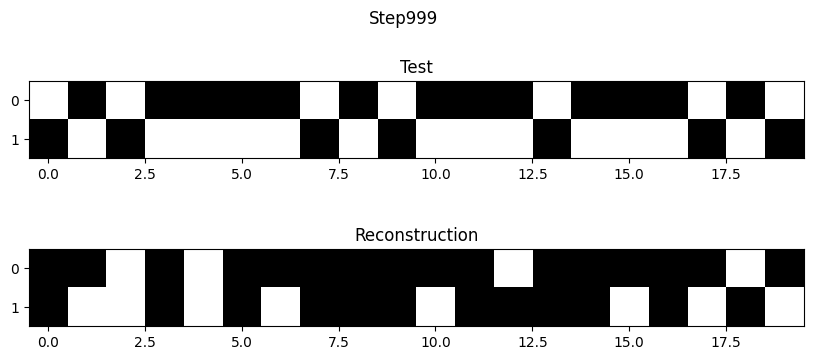

In [113]:
maxtrain = np.max(df.epoch)
show = [-1, maxtrain]
# show = np.arange(0, maxtrain, 40)
# show = np.arange(0, 30, 5)
# show = [maxtrain]
# show = np.arange(10)
for epoch in show:
    row = df[df.epoch == epoch].iloc[0]

    Vtest = np.array(row.Vtest).T
    Vrecon = np.array(row.Vrecon).T
    MSE = np.mean(np.linalg.norm(Vtest-Vrecon, axis=0))
    print(MSE)

    fig, (ax1, ax2) = plt.subplots(2,1, figsize=(10,4))
    fig.suptitle("Step{}".format(epoch))
    ax1.imshow(Vtest, cmap='binary')
    ax1.set_title('Test')
#     plt.show()
    ax2.imshow(Vrecon, cmap='binary')
    ax2.set_title("Reconstruction")
#     fig.savefig('figures/')
    plt.show()
    # Vrecons

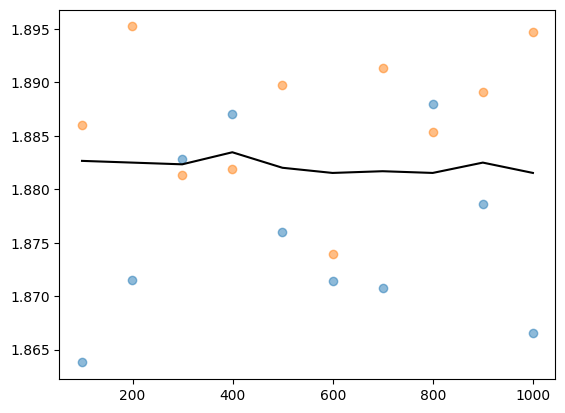

In [114]:
plt.plot(df.epoch, df.analogZero, c='k', zorder=5)
plt.scatter(df.epoch, df.aH0, alpha=0.5)
plt.scatter(df.epoch, df.aH1, alpha=0.5)
plt.show()

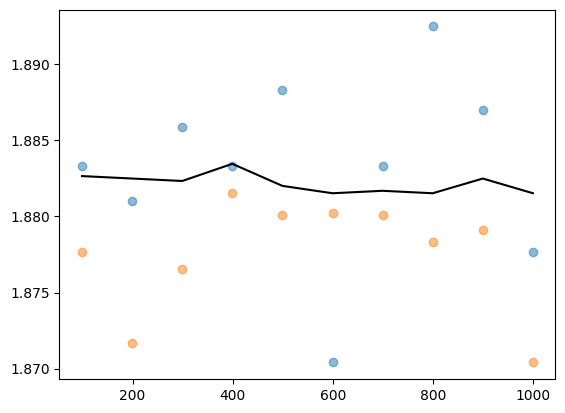

In [115]:
plt.plot(df.epoch, df.analogZero, c='k', zorder=5)
plt.scatter(df.epoch, df.aV0, alpha=0.5)
plt.scatter(df.epoch, df.aV1, alpha=0.5)
plt.show()